# D-08 — Arquiteturas Físicas do Qubit

- **Tipo:** Digressão
- **Referenciado por:** [D-00](D-00.ipynb), [D-07](D-07.ipynb)

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">etimologia</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Coerência</b> vem do latim <i>cohaerere</i>: <i>co-</i> ("junto") + <i>haerere</i> ("aderir", "estar preso"). A ideia original é a de partes que ficam unidas, que se mantêm conectadas. Em física quântica, coerência descreve a manutenção das relações de fase entre as amplitudes — o que permite interferência. Perder coerência é perder essas relações.<br><b>Decoerência</b> é o processo inverso: o sistema quântico se acopla ao ambiente e as fases se embaralham. A superposição não colapsa de forma controlada — ela vaza para o entorno de forma irreversível.</span>
</div>

## Afirmação introdutória

Um qubit pode ser qualquer sistema físico de dois níveis que obedeça à mecânica quântica — mas construir um que seja `preparável`, `manipulável` e `medível` com coerência suficiente para executar algoritmos é extraordinariamente difícil. Diferentes tecnologias físicas fazem compromissos diferentes entre coerência, conectividade, escalabilidade e velocidade de porta.

## 1. O que toda arquitetura precisa garantir

Independente da tecnologia, qualquer implementação física de qubit precisa satisfazer os `critérios de DiVincenzo` (2000):

1. **Sistema escalável** com qubits bem caracterizados
2. **Preparação** do estado inicial em estado conhecido (e.g., |0⟩)
3. **Tempo de coerência** muito maior que o tempo de porta
4. **Conjunto universal de portas** — pelo menos H, CNOT, T
5. **Medição** qubit-a-qubit com alta fidelidade

Nenhuma tecnologia atual satisfaz todos os cinco com a fidelidade e escala necessárias para algoritmos como o de Shor em instâncias grandes. O estado da arte é ruído — daí o nome `NISQ` (Noisy Intermediate-Scale Quantum).

## 2. Supercondutores — o caminho dominante

A arquitetura de maior tração hoje (IBM, Google) usa circuitos supercondutores resfriados a ~15 mK — mais frio que o espaço interestelar.

**O `transmon`** (Koch et al., 2007) é o design dominante: uma caixa de pares de Cooper com um grande capacitor. O qubit são os dois níveis de energia mais baixos do circuito LC quântico.

A `junção de Josephson` é o componente-chave: dois supercondutores separados por uma barreira fina. Ela introduce não-linearidade no potencial — sem ela, os níveis de energia seriam igualmente espaçados e não seria possível endereçar seletivamente a transição |0⟩↔|1⟩.

**Vantagens:** manufatura com técnicas de microfabricação padrão, portas rápidas (~10–50 ns), integração elétrica.

**Desafios:** `decoerência` por ruído de carga e de fluxo magnético, requer refrigeração extrema, conectividade limitada entre qubits.

**Evolução de coerência:** de ~nanosegundos (Nakamura, 1999) para ~milissegundos (estado da arte atual) — seis ordens de magnitude em 25 anos.

## 3. Íons aprisionados — a mais precisa

Proposta por Cirac e Zoller (1995), usa dois níveis eletrônicos de íons (e.g., $^{171}$Yb$^+$, $^{40}$Ca$^+$) aprisionados por campos eletromagnéticos em vácuo ultra-alto.

Portas são realizadas por pulsos de laser calibrados para induzir transições entre os níveis.

**Vantagens:** fidelidade de porta altíssima (>99.9%), coerência de segundos a horas, todos os qubits são idênticos por natureza (`conectividade all-to-all`).

**Desafios:** portas lentas (~1–10 µs), escalabilidade difícil (o trap físico limita o número de íons), sensibilidade a vibrações.

## 4. Outras arquiteturas

**Átomos neutros em tweezer arrays.** Átomos aprisionados por feixes de laser focalizados. Reconfigurabilidade alta — você pode mover os átomos. Escalabilidade promissora (centenas de qubits demonstrados). Atividade recente intensa.

**Fótons.** O qubit é a polarização ou o caminho de um fóton. Opera à temperatura ambiente. `Portas probabilísticas` — a porta só funciona com certa probabilidade, o que exige estratégias de correção. Atrativo para comunicação quântica e redes.

**Spins em semicondutores (quantum dots).** Dois estados de spin de elétron em estruturas de silício ou GaAs. Muito pequenos — potencial de integração com CMOS. Fidelidade e coerência ainda em desenvolvimento.

**Computação topológica (anyons).** Proposta por Kitaev (1997). O qubit é codificado na topologia global de quasipartículas — `anyons`. Erros locais não afetam a informação. Altamente resistente a ruído. Ainda sem demonstração experimental definitiva.

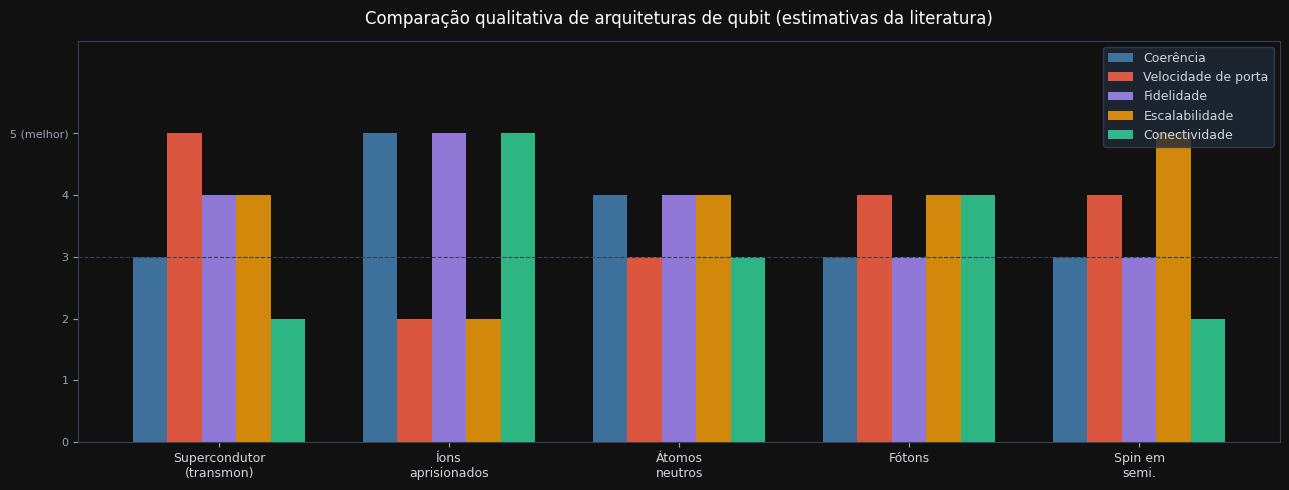

Nenhuma arquitetura domina em todos os critérios.
Supercondutores lideram em adoção; íons em fidelidade; átomos neutros em escalabilidade emergente.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ── Comparação qualitativa das arquiteturas ──────────────────────────────────
arquiteturas = ['Supercondutor\n(transmon)', 'Íons\naprisionados', 'Átomos\nneutros', 'Fótons', 'Spin em\nsemi.']

# Escores 0-5 (estimativa qualitativa baseada na literatura)
criterios = {
    'Coerência':         [3, 5, 4, 3, 3],
    'Velocidade de porta': [5, 2, 3, 4, 4],
    'Fidelidade':        [4, 5, 4, 3, 3],
    'Escalabilidade':    [4, 2, 4, 4, 5],
    'Conectividade':     [2, 5, 3, 4, 2],
}

x = np.arange(len(arquiteturas))
n_criterios = len(criterios)
width = 0.15
colors_bars = ['steelblue', 'tomato', '#a78bfa', '#f59e0b', '#34d399']

fig, ax = plt.subplots(figsize=(13, 5), facecolor='#111')
fig.patch.set_facecolor('#111')
ax.set_facecolor('#111')
ax.tick_params(colors='#9ca3af')
for spine in ax.spines.values():
    spine.set_edgecolor('#374151')

for i, (criterio, valores) in enumerate(criterios.items()):
    offset = (i - n_criterios / 2 + 0.5) * width
    ax.bar(x + offset, valores, width, label=criterio,
           color=colors_bars[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(arquiteturas, color='#d1d5db', fontsize=9)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['0', '1', '2', '3', '4', '5 (melhor)'], color='#9ca3af', fontsize=8)
ax.set_ylim(0, 6.5)
ax.set_title('Comparação qualitativa de arquiteturas de qubit (estimativas da literatura)',
             color='white', pad=12)
ax.legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937',
          edgecolor='#374151', loc='upper right')
ax.axhline(3, color='#374151', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

print('Nenhuma arquitetura domina em todos os critérios.')
print('Supercondutores lideram em adoção; íons em fidelidade; átomos neutros em escalabilidade emergente.')

## O que este notebook respondeu

Diferentes tecnologias físicas implementam o mesmo modelo matemático de qubit, mas fazem compromissos distintos entre coerência, velocidade, fidelidade, escalabilidade e conectividade. Supercondutores dominam hoje pelo ecossistema industrial; íons aprisionados lideram em fidelidade; átomos neutros emergem em escalabilidade. Nenhuma tecnologia satisfaz todos os critérios de DiVincenzo com escala e fidelidade suficientes para algoritmos com impacto real.

## O que este notebook não respondeu

- Como as portas quânticas são implementadas fisicamente em cada plataforma
- O que `NISQ` implica em termos de quais algoritmos são executáveis hoje
- Como a correção de erros de superfície funciona e qual o overhead de qubits físicos por qubit lógico